**Importing the necessary libraries**


In [ ]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.5
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

In [ ]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

**Preparing the dataset**

In [ ]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip "/content/drive/MyDrive/Socket_Type_v4.zip"

Archive:  /content/drive/MyDrive/Socket_Type_v4.zip
   creating: Socket_Type_v4/
   creating: Socket_Type_v4/A_Type/
  inflating: Socket_Type_v4/A_Type/A-2_jpg.rf.1da9d35450c39af26420154960eddcc6.jpg  
  inflating: Socket_Type_v4/A_Type/A-2_jpg.rf.2d9e5a8f2a74d571ec93a12ac844877c.jpg  
  inflating: Socket_Type_v4/A_Type/A-2_jpg.rf.8b73865b4c66bed5a9e7340c2107277a.jpg  
  inflating: Socket_Type_v4/A_Type/A-4_png.rf.37278628e2105470e87a063599aee786.jpg  
  inflating: Socket_Type_v4/A_Type/A-4_png_jpg.rf.1a0b1f7cc051a208229f83bc3a98047b.jpg  
  inflating: Socket_Type_v4/A_Type/A-4_png_jpg.rf.8d4d0aa14654ce59d9b45e3ed8e408ad.jpg  
  inflating: Socket_Type_v4/A_Type/A-5_jpg.rf.23bca9985eae09b56316122c4e45ce93.jpg  
  inflating: Socket_Type_v4/A_Type/A-5_jpg.rf.3b26f317c63800bea2ee0826bfa93aab.jpg  
  inflating: Socket_Type_v4/A_Type/A-5_jpg.rf.c924d73e4f4b8a72c60d9225fb57f4d7.jpg  
  inflating: Socket_Type_v4/A_Type/A-6_jpg.rf.69b21cbc45a7abd0333a50014db649f5.jpg  
  inflating: Socket_Type_

**Split the dataset into train valid and test**

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders
input_folder="/content/Socket_Type_v4/"
splitfolders.ratio(input_folder, output="output", seed=1337, ratio=(0.8, 0.1, 0.1))

Copying files: 3560 files [00:00, 6298.37 files/s]


In [ ]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = '/content/output/train/'
valid_path = '/content/output/val/'
test_path='/content/output/test/'

In [ ]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   horizontal_flip = True)
valid_datagen=ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
# Make sure you provide the same target size as initialied for the image size
train_set = train_datagen.flow_from_directory('/content/output/train/',
                                                 target_size = (224, 224),
                                                 batch_size = 16,
                                                 class_mode = 'categorical')

Found 2839 images belonging to 13 classes.


In [ ]:
val_set = valid_datagen.flow_from_directory('/content/output/val/',
                                                 target_size = (224, 224),
                                                 batch_size = 16,
                                                 class_mode = 'categorical')

Found 353 images belonging to 13 classes.


In [ ]:
test_set = valid_datagen.flow_from_directory('/content/output/test/',
                                                 target_size = (224, 224),
                                                 batch_size = 16,
                                                 class_mode = 'categorical')

Found 364 images belonging to 13 classes.


In [ ]:
num_classes = len(train_set.class_indices)

In [ ]:
# 3. MODEL CREATION FUNCTION
# ==============================
from tensorflow.keras.applications import VGG16, InceptionV3, Xception, ResNet50, ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, GlobalAveragePooling2D

def create_model(base_model_name, input_shape=IMAGE_SIZE + [3], num_classes=num_classes):
    if base_model_name == "VGG16":
        base_model = VGG16(input_shape=input_shape, weights='imagenet', include_top=False)
    elif base_model_name == "InceptionV3":
        base_model = InceptionV3(input_shape=input_shape, weights='imagenet', include_top=False)
    elif base_model_name == "Xception":
        base_model = Xception(input_shape=input_shape, weights='imagenet', include_top=False)
    elif base_model_name == "ResNet50":
        base_model = ResNet50(input_shape=input_shape, weights='imagenet', include_top=False)
    elif base_model_name == "ResNet101":
        base_model = ResNet101(input_shape=input_shape, weights='imagenet', include_top=False)
    else:
        raise ValueError("Unknown model name")

    # Freeze base model
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
# 4. INITIALIZE MODELS
# ==============================
model_names = ["VGG16", "InceptionV3", "Xception", "ResNet50", "ResNet101"]
models_dict = {name: create_model(name) for name in model_names}


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# 5. TRAIN MODELS
# ==============================
histories = {}
for name, model in models_dict.items():
    print(f"\nTraining {name} ...")
    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=10,
        steps_per_epoch=len(train_set),
        validation_steps=len(val_set)
    )
    histories[name] = history


Training VGG16 ...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


178/178 ━━━━━━━━━━━━━━━━━━━━ 39s 160ms/step - accuracy: 0.2294 - loss: 2.4272 - val_accuracy: 0.5297 - val_loss: 2.0023
Epoch 2/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.5340 - loss: 1.8831 - val_accuracy: 0.5552 - val_loss: 1.7122
Epoch 3/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.6203 - loss: 1.5859 - val_accuracy: 0.6317 - val_loss: 1.5276
Epoch 4/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.6372 - loss: 1.4326 - val_accuracy: 0.6374 - val_loss: 1.4037
Epoch 5/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.6752 - loss: 1.2944 - val_accuracy: 0.6572 - val_loss: 1.3217
Epoch 6/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.6902 - loss: 1.2171 - val_accuracy: 0.7054 - val_loss: 1.2302
Epoch 7/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.7116 - loss: 1.1563 - val_accuracy: 0.7252 - val_loss: 1.1639
Epoch 8/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.7325 - loss: 1.0893 - val

Found 364 images belonging to 13 classes.
Detected classes (13): ['A_Type', 'B_Type', 'C_Type', 'DM_Type', 'E_Type', 'F_Type', 'G_Type', 'H_Type', 'I_Type', 'JN_Type', 'K_Type', 'L_Type', 'O_Type']
Evaluating VGG16 ...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 363ms/step
Evaluating InceptionV3 ...
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 452ms/step
Evaluating Xception ...
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 670ms/step
Evaluating ResNet50 ...
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 282ms/step
Evaluating ResNet101 ...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 386ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Models included in ensemble (accuracy >= 65%): ['VGG16', 'InceptionV3', 'Xception']

Ensemble Accuracy: 95.05%

Classification Report:
               precision    recall  f1-score   support

      A_Type       1.00      1.00      1.00        31
      B_Type       0.81      1.00      0.89        29
      C_Type       0.84      1.00      0.91        31
     DM_Type       0.97      1.00      0.99        33
      E_Type       1.00      0.97      0.99        34
      F_Type       1.00      0.84      0.92        32
      G_Type       1.00      0.91      0.95        33
      H_Type       0.94      0.89      0.92        19
      I_Type       1.00      0.92      0.96        25
     JN_Type       0.89      0.93      0.91        27
      K_Type       1.00      0.97      0.98        32
      L_Type       1.00      0.92      0.96        25
      O_Type       1.00      1.00      1.00        13

    accuracy                           0.95       364
   macro avg       0.96      0.95      0.95       3

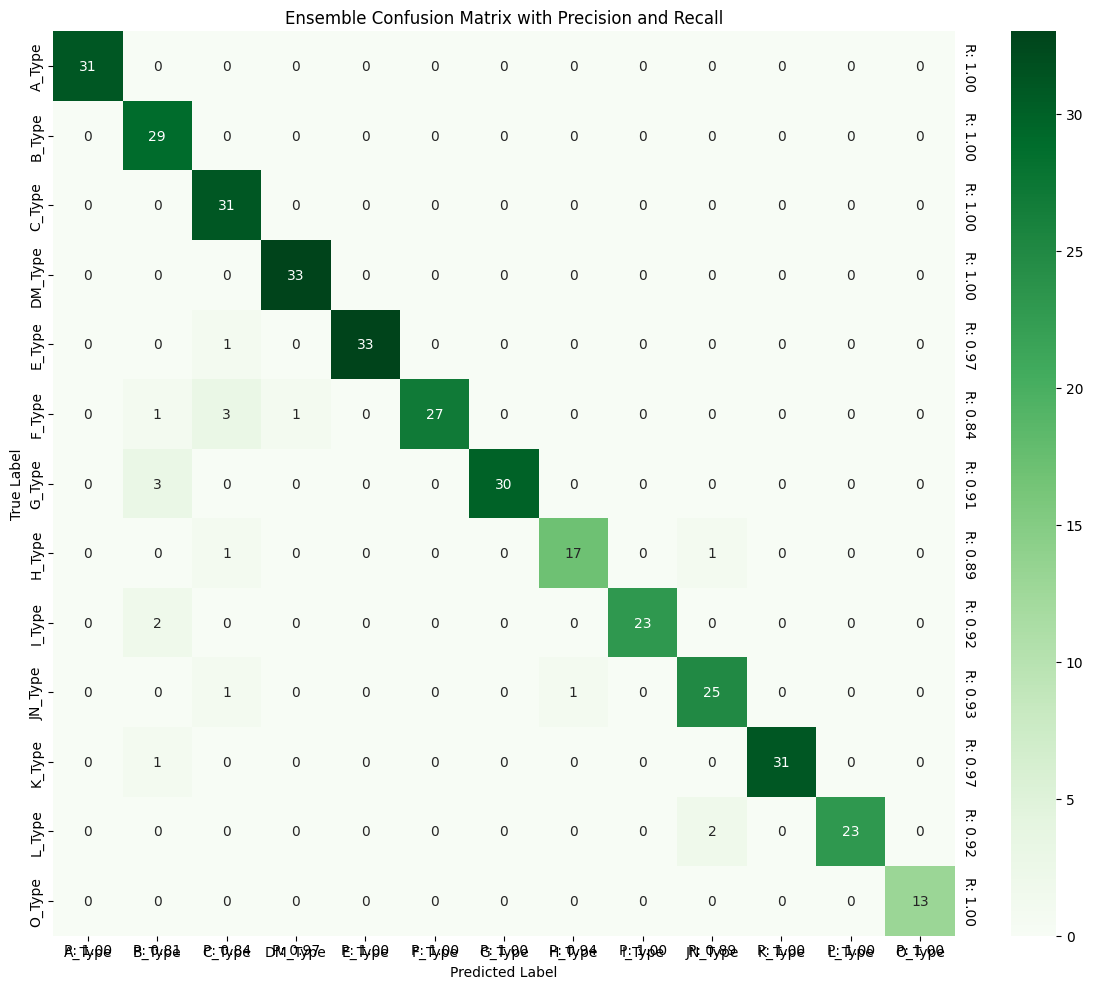


Ensemble model saved as 'Socket_Type_v4_ensemble.h5'


In [ ]:
# ==============================
# IMPORTS
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# SETTINGS
# ==============================
IMAGE_SIZE = [224, 224]
BATCH_SIZE = 16
ACCURACY_THRESHOLD = 0.65  # minimum accuracy to include model in ensemble

# ==============================
# LOAD TEST/VALIDATION DATA
# ==============================
test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(
    '/content/output/test',  # path to test/validation folder
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # important for labels
    shuffle=False
)

# Automatically detect class names
classes = list(test_set.class_indices.keys())
print(f"Detected classes ({len(classes)}): {classes}")

# ==============================
# DICTIONARY OF MODELS
# ==============================
# Example: models_dict = {'VGG16': vgg16_model, 'InceptionV3': inception_model, 'Xception': xception_model,
#                          'ResNet50': resnet50_model, 'ResNet101': resnet101_model}

# ==============================
# 1. Evaluate individual models
# ==============================
metrics_dict = {}
y_true = np.array(test_set.labels)

for name, model in models_dict.items():
    print(f"Evaluating {name} ...")
    test_set.reset()
    y_pred_probs = model.predict(test_set, verbose=1)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred_classes)
    report = classification_report(y_true, y_pred_classes, target_names=classes, output_dict=True)

    metrics_dict[name] = {
        "accuracy": acc,
        "classification_report": report,
        "y_pred_probs": y_pred_probs
    }

# ==============================
# 2. Filter models for ensemble
# ==============================
valid_models = [name for name, m in metrics_dict.items() if m["accuracy"] >= ACCURACY_THRESHOLD]
print(f"\nModels included in ensemble (accuracy >= {ACCURACY_THRESHOLD*100:.0f}%): {valid_models}")

# ==============================
# 3. Ensemble Predictions (Soft Voting)
# ==============================
ensemble_metrics = None
if len(valid_models) > 0:
    all_preds = [metrics_dict[name]["y_pred_probs"] for name in valid_models]
    ensemble_preds = np.mean(all_preds, axis=0)
    final_preds = np.argmax(ensemble_preds, axis=1)

    ensemble_acc = accuracy_score(y_true, final_preds)
    ensemble_report = classification_report(y_true, final_preds, target_names=classes, output_dict=True)
    conf_matrix = confusion_matrix(y_true, final_preds)

    ensemble_metrics = {
        "accuracy": ensemble_acc,
        "classification_report": ensemble_report,
        "conf_matrix": conf_matrix
    }

    print(f"\nEnsemble Accuracy: {ensemble_acc*100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_true, final_preds, target_names=classes))

# ==============================
# 4. Performance Summary Table
# ==============================
summary_data = []
for name in metrics_dict.keys():
    report = metrics_dict[name]["classification_report"]
    precision = np.mean([v['precision'] for k,v in report.items() if k in classes])
    recall = np.mean([v['recall'] for k,v in report.items() if k in classes])
    f1 = np.mean([v['f1-score'] for k,v in report.items() if k in classes])
    summary_data.append([name, metrics_dict[name]["accuracy"], precision, recall, f1])

# Add ensemble metrics
if ensemble_metrics is not None:
    report = ensemble_metrics["classification_report"]
    precision = np.mean([v['precision'] for k,v in report.items() if k in classes])
    recall = np.mean([v['recall'] for k,v in report.items() if k in classes])
    f1 = np.mean([v['f1-score'] for k,v in report.items() if k in classes])
    summary_data.append(["Ensemble", ensemble_metrics["accuracy"], precision, recall, f1])

summary_df = pd.DataFrame(summary_data, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
print("\nPerformance Summary:")
print(summary_df)

# ==============================
# 5. Improvement of Ensemble over Individual Models
# ==============================
if ensemble_metrics is not None:
    print("\nImprovement of Ensemble over individual models:")
    for name in valid_models:
        improvement = (ensemble_metrics["accuracy"] - metrics_dict[name]["accuracy"]) * 100
        print(f"{name} -> Improvement: {improvement:.2f}%")

# ==============================
# 6. Confusion Matrix for Ensemble
# ==============================
if ensemble_metrics is not None:
    plt.figure(figsize=(12,10))
    sns.heatmap(ensemble_metrics["conf_matrix"], annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Greens")

    precision = np.diag(ensemble_metrics["conf_matrix"]) / np.sum(ensemble_metrics["conf_matrix"], axis=0)
    recall = np.diag(ensemble_metrics["conf_matrix"]) / np.sum(ensemble_metrics["conf_matrix"], axis=1)

    for i in range(len(classes)):
        plt.text(i + 0.5, len(classes) + 0.2, f"P: {precision[i]:.2f}", ha="center", va="center", fontsize=10)
        plt.text(len(classes) + 0.2, i + 0.5, f"R: {recall[i]:.2f}", ha="center", va="center", fontsize=10, rotation=270)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Ensemble Confusion Matrix with Precision and Recall")
    plt.tight_layout()
    plt.show()

# ==============================
# 7. Save Ensemble Model
# ==============================
model.save('Socket_Type_v4_ensemble.h5')
print("\nEnsemble model saved as 'Socket_Type_v4_ensemble.h5'")

